# Super manual segmentation

I need to do the manual segmentation from TLS point clouds for a looot of trees and I want to speed up the processing.
The segmentation happends in RiSCAN Pro ... which unfortunately it is very hard to script

However I have QGIS to keep tracks of the trees and I want to make the life easier. The things I should do are:

- rename the trees to a memorable name (I am thinking to use max 5 letters latin names of animals). Now they are named after cells and those names are way too long and wayy to similar
- arrange the names in a smart way? so to maximise neightbouring cells with the same letter. I think we could use some kind of space filling curve
- automatically list neighbouring trees in QGIS


example of the trees

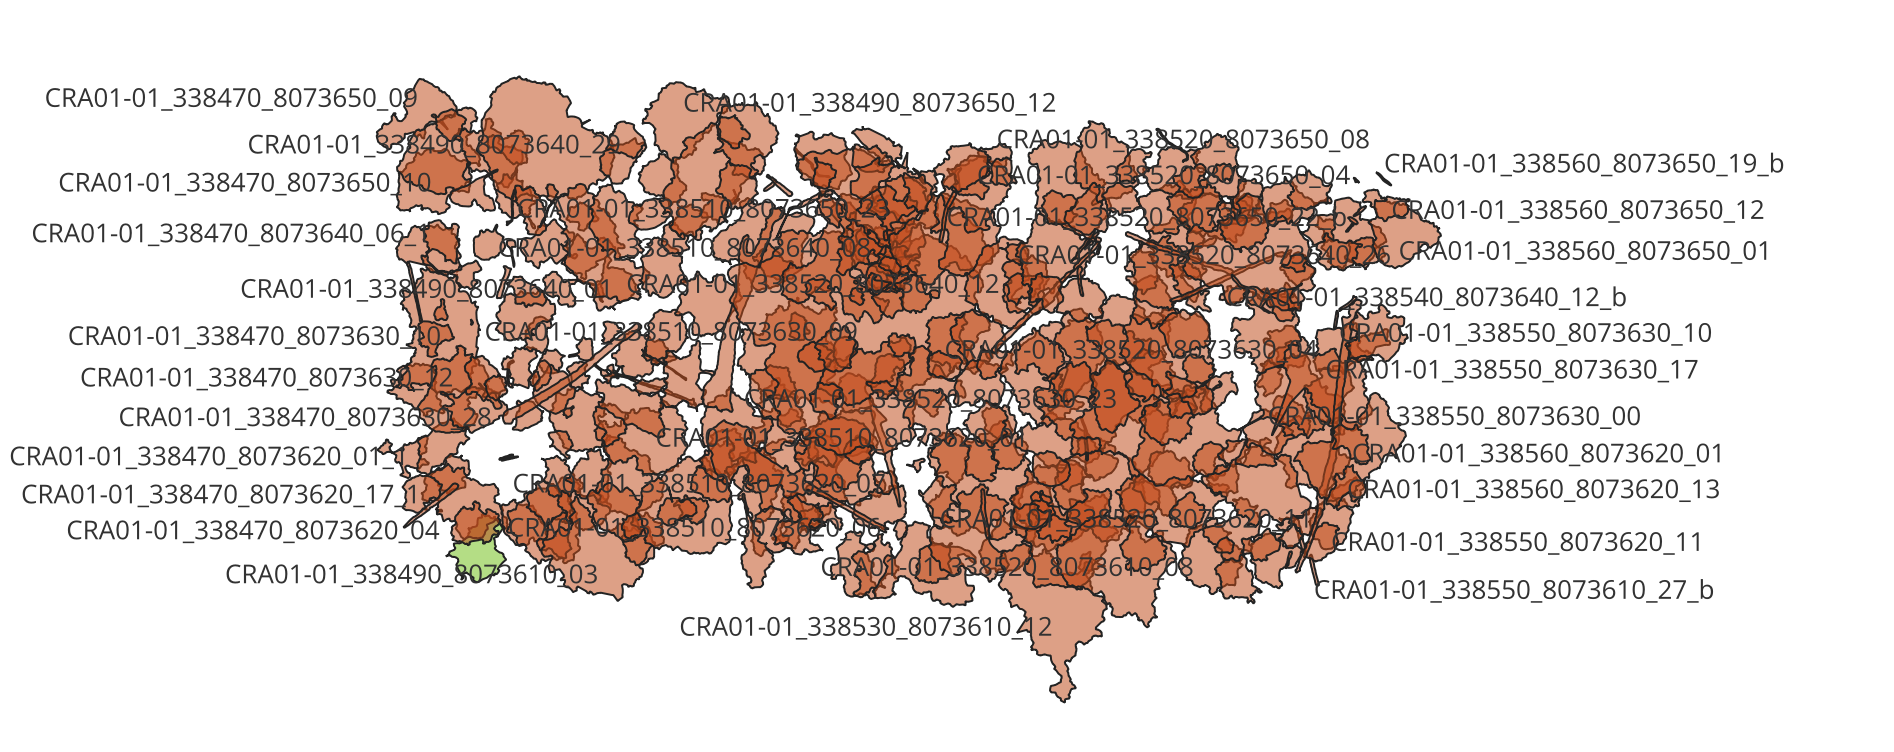


In [ ]:
import geopandas as gpd
import pandas as pd

df = gpd.read_file("the_crater_crowns.gpkg")
df

,GIS_ID,ID_number,area,area.1,neighbors,neighbors_truncated,Segmented,geometry
0,CRA01-01_338470_8073610_20_1,338470_8073610_20,18.991232,18.991232,"338470_8073620_08,338470_8073620_09,338480_807...",False,1.0,"POLYGON ((338479.11 8073616.981, 338479.064 80..."
1,CRA01-01_338470_8073620_01_1,338470_8073620_01,7.219352,7.219352,"338470_8073620_05,338470_8073620_07,338470_807...",False,NaN,"POLYGON ((338472.7 8073626.952, 338472.697 807..."
2,CRA01-01_338470_8073620_04,338470_8073620_04,0.083854,0.083854,"338470_8073620_08,338470_8073620_17,338470_807...",False,NaN,"POLYGON ((338478.236 8073621.118, 338478.235 8..."
3,CRA01-01_338470_8073620_05,338470_8073620_05,13.895950,13.895950,"338470_8073620_01,338470_8073620_07,338470_807...",False,NaN,"POLYGON ((338476.481 8073624.928, 338476.496 8..."
4,CRA01-01_338470_8073620_07_1,338470_8073620_07,7.821606,7.821606,"338470_8073620_05,338470_8073620_08,338470_807...",False,NaN,"POLYGON ((338477.699 8073624.457, 338477.715 8..."
...,...,...,...,...,...,...,...,...
340,CRA01-01_338560_8073650_21_b,338560_8073650_21,0.119861,0.119861,338560_8073650_01,False,NaN,"POLYGON ((338563.888 8073652.371, 338563.897 8..."
341,CRA01-01_338560_8073650_23_b,338560_8073650_23,0.287928,0.287928,"338550_8073650_17,338560_8073650_25,338560_807...",False,NaN,"POLYGON ((338563.377 8073648.635, 338563.386 8..."
342,CRA01-01_338560_8073650_24_b,338560_8073650_24,0.330185,0.330185,"338550_8073650_17,338560_8073650_01,338560_807...",False,NaN,"POLYGON ((338563.881 8073648.796, 338563.884 8..."
343,CRA01-01_338560_8073650_25_b,338560_8073650_25,0.154486,0.154486,"338550_8073650_17,338560_8073650_23,338560_807...",False,NaN,"POLYGON ((338563.169 8073647.346, 338563.168 8..."


,GIS_ID,ID_number,area,area.1,neighbors,neighbors_truncated,Segmented,geometry
0,CRA01-01_338470_8073610_20_1,338470_8073610_20,18.991232,18.991232,"338470_8073620_08,338470_8073620_09,338480_807...",False,1.0,"POLYGON ((338479.11 8073616.981, 338479.064 80..."
1,CRA01-01_338470_8073620_01_1,338470_8073620_01,7.219352,7.219352,"338470_8073620_05,338470_8073620_07,338470_807...",False,NaN,"POLYGON ((338472.7 8073626.952, 338472.697 807..."
2,CRA01-01_338470_8073620_04,338470_8073620_04,0.083854,0.083854,"338470_8073620_08,338470_8073620_17,338470_807...",False,NaN,"POLYGON ((338478.236 8073621.118, 338478.235 8..."
3,CRA01-01_338470_8073620_05,338470_8073620_05,13.895950,13.895950,"338470_8073620_01,338470_8073620_07,338470_807...",False,NaN,"POLYGON ((338476.481 8073624.928, 338476.496 8..."
4,CRA01-01_338470_8073620_07_1,338470_8073620_07,7.821606,7.821606,"338470_8073620_05,338470_8073620_08,338470_807...",False,NaN,"POLYGON ((338477.699 8073624.457, 338477.715 8..."
...,...,...,...,...,...,...,...,...
340,CRA01-01_338560_8073650_21_b,338560_8073650_21,0.119861,0.119861,338560_8073650_01,False,NaN,"POLYGON ((338563.888 8073652.371, 338563.897 8..."
341,CRA01-01_338560_8073650_23_b,338560_8073650_23,0.287928,0.287928,"338550_8073650_17,338560_8073650_25,338560_807...",False,NaN,"POLYGON ((338563.377 8073648.635, 338563.386 8..."
342,CRA01-01_338560_8073650_24_b,338560_8073650_24,0.330185,0.330185,"338550_8073650_17,338560_8073650_01,338560_807...",False,NaN,"POLYGON ((338563.881 8073648.796, 338563.884 8..."
343,CRA01-01_338560_8073650_25_b,338560_8073650_25,0.154486,0.154486,"338550_8073650_17,338560_8073650_23,338560_807...",False,NaN,"POLYGON ((338563.169 8073647.346, 338563.168 8..."


In [ ]:
df.GIS_ID

0                           CRA01-01_338470_8073610_20_1
1                           CRA01-01_338470_8073620_01_1
2                             CRA01-01_338470_8073620_04
3                             CRA01-01_338470_8073620_05
4                           CRA01-01_338470_8073620_07_1
                             ...                        
340                         CRA01-01_338560_8073650_21_b
341                         CRA01-01_338560_8073650_23_b
342                         CRA01-01_338560_8073650_24_b
343                         CRA01-01_338560_8073650_25_b
344    sylvera_trees - POINTCLOUDS - 0013AU_CRA01-01_...
Name: GIS_ID, Length: 345, dtype: object

0                           CRA01-01_338470_8073610_20_1
1                           CRA01-01_338470_8073620_01_1
2                             CRA01-01_338470_8073620_04
3                             CRA01-01_338470_8073620_05
4                           CRA01-01_338470_8073620_07_1
                             ...                        
340                         CRA01-01_338560_8073650_21_b
341                         CRA01-01_338560_8073650_23_b
342                         CRA01-01_338560_8073650_24_b
343                         CRA01-01_338560_8073650_25_b
344    sylvera_trees - POINTCLOUDS - 0013AU_CRA01-01_...
Name: GIS_ID, Length: 345, dtype: object

regex to extract the cell number, aka 338470_8073610

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Looking at your GIS_ID values, I can see the pattern. The cell number appears after the prefix "CRA01-01_" and consists of two 6-digit numbers separated by an underscore.

Here's a regex pattern that will extract that:

```python
r'(\d{6}_\d{7})'
```

This captures 6 digits, an underscore, then 7 digits (since your second number is 7 digits like 8073610).

Want to test it on your dataframe to see if it works for all your tree IDs?

In [ ]:
df['cell_id'] = df.GIS_ID.str.extract(r'(\d{6}_\d{7})').squeeze()
len(df['cell_id'].unique())

48

48

Find an authorative list of genera of animals names

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Great! There are several authoritative sources for animal genera:

**Most authoritative options:**

1. [*](https://www.catalogueoflife.org/ "COL | The Catalogue of Life") **Catalogue of Life** (catalogueoflife.org) - described as "the most complete authoritative list of the world's species"

2. [*](https://www.itis.gov/ "ITIS.gov | Integrated Taxonomic Information System (ITIS)") [*](https://guides.lib.wayne.edu/biologicalsciences/taxonomy "Animal & Plant Information/Taxonomy - Biological Sciences - Research Guides at Wayne State University") **ITIS** (Integrated Taxonomic Information System at itis.gov) - provides authoritative taxonomic information on animals of North America and the world, and [*](https://biology.stackexchange.com/questions/14059/is-there-a-downloadable-list-of-all-species-along-with-their-traditional-classif "taxonomy - Is there a downloadable list of all species along with their traditional classification? - Biology Stack Exchange") you can download the data in several formats

3. [*](https://www.gbif.org/dataset/d7dddbf4-2cf0-4f39-9b2a-bb099caae36c "GBIF Backbone Taxonomy") **GBIF Backbone Taxonomy** - a comprehensive classification covering all names, allowing integration of name-based information from different resources

Since you need 48 genera names (max 5 letters), would you like me to help you access one of these databases, or would you prefer to manually curate a list of short animal genera names yourself?

I want to get a pandas df with something like a few thousands species names so then I can do the filtering on top

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Got it! Let me help you get a pandas DataFrame with species/genera names that you can filter.The easiest options I found are:

1. **ITIS (Integrated Taxonomic Information System)** - [*](https://biology.stackexchange.com/questions/14059/is-there-a-downloadable-list-of-all-species-along-with-their-traditional-classif "taxonomy - Is there a downloadable list of all species along with their traditional classification? - Biology Stack Exchange") downloadable as a database or pipe-delimited text files, comprehensive and authoritative

2. **GitHub CSV** - [*](https://gist.github.com/EyeOfMidas/311e77b8b8c2f334fc8bdaf652c1f47f "A simple csv of animal names - scraped from https://a-z-animals.com/animals/ · GitHub") A simple csv of animal names scraped from a-z-animals.com

3. **Kaggle dataset** - Has animal names ready to use

Which approach sounds best to you? The ITIS database is most authoritative but requires more processing. The GitHub/Kaggle options are simpler CSV files you can load directly into pandas.

Would you like me to show you how to load one of these, or would you prefer a different source?

give me the link to the kaggle dataset

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here are a couple of Kaggle datasets with animal names:

1. [*](https://www.kaggle.com/datasets/pybear/animalsnames "Animals names | Kaggle") **Animals names** - https://www.kaggle.com/datasets/pybear/animalsnames

2. [*](https://www.kaggle.com/datasets/iamsouravbanerjee/animal-information-dataset "Animal Information Dataset | Kaggle") **Animal Information Dataset** - https://www.kaggle.com/datasets/iamsouravbanerjee/animal-information-dataset

The first one looks like it's specifically for animal names (text data), while the second has more detailed animal information. 

Which one would you like to try, or should I help you find the download link for one of them?

Those are not latin names ... Can you suggest other categories of objects that would work?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good point! Latin genus names would be more systematic. Here are some alternative categories of short names you could use:

1. **Chemical elements** - Many are 1-5 letters (H, He, C, Au, Fe, etc.) and there are 118 of them
2. **Greek letters** - Alpha, Beta, Gamma, Delta, etc. (though some are longer)
3. **Constellations** - Some have short names (Ara, Leo, Crux, Lynx, etc.)
4. **Minerals/gems** - Ruby, Jade, Onyx, etc.
5. **Colors** - Short color names in various languages
6. **Phonetic alphabet** - Alpha, Bravo, Charlie (though many exceed 5 letters)

For your 48 cells, **chemical elements** might work really well - they're universally recognized, systematically organized, and many have very short symbols.

Which category appeals to you, or would you like to stick with finding proper Latin genus names?

some plots have at least double the size so i should have 100+ names

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Ah, good catch! You'll need 100+ names to have enough options.

For that many, here are your best bets:

1. **Chemical elements** - 118 total, many with short symbols (though full names can be longer)
2. **Greek/Roman gods and mythological figures** - Hundreds available, many short names
3. **Stars** - Thousands of named stars, many with short traditional names
4. **Cities** - Short city names from around the world
5. **Latin genus names** - Still the most systematic option if we can find a good source

For Latin genera, we could try:
- Downloading the ITIS database directly
- Using a biology API
- Web scraping a taxonomy site

Which direction interests you most? Or would you like me to help you quickly get a list of one of the non-Latin categories to move forward?

can you help me easily download ITIS database stuff and query it?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! ITIS has a few ways to access their data. The easiest for your needs is probably their API or downloading their database files.

**Option 1: ITIS Web Service API** - Query directly from Python without downloading
**Option 2: Download SQLite database** - Full offline access to all data

For quick genus name extraction, the API approach would be simpler. Would you like to try that first?

If yes, we can use the `requests` library to query their API. Want me to show you a small example of how to fetch some genus names?

let's use the API, can we query all short names?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Looking at the ITIS API, we can search for taxonomic names, but there isn't a direct "give me all short genus names" query. 

We'd need to either:
1. Search by taxonomic rank (like "genus") and page through results
2. Download their full database and filter locally

The API has rate limits and pagination, so getting thousands of names might be slow.

**Alternative idea:** Would you be open to using a pre-compiled list? I could help you scrape a Wikipedia page of animal genera, or we could use the simple approach of downloading the ITIS SQLite database file (it's free) and querying it locally with pandas/sqlite3.

Which sounds better - work with the API despite limitations, or download the database for easier filtering?

when I selected a polygon in QGIS I want to get the list of names all polygons that intersects with a 5m buffer. It should be a single click action

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

To create a single-click action that shows intersecting polygon names within a 5m buffer in QGIS, you'll want to use an **Action** with a Python expression.

Here's the general approach:
1. Go to Layer Properties → Actions
2. Create a new action that runs Python code
3. Use the action to buffer the clicked polygon and find intersections

Before I give you the specific code, a few questions:

- What's the name of the field that contains the polygon names you want to display?
- Do you want the results shown in a message box, printed to the console, or somewhere else?
- Are both the clicked polygon and the polygons you're checking against in the same layer, or different layers?

ok I am downloading the sqlite database locally. Can we build a query? I want the genera name sorted by lenght and then alphabetically

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great! Once you have the SQLite database downloaded, we can query it.

The ITIS database typically has a table called `taxonomic_units` with fields like `rank_id` (genus is usually rank_id = 180) and `complete_name` for the scientific name.

Here's a basic query structure:

```python
import sqlite3
import pandas as pd

conn = sqlite3.connect('path_to_your_itis.sqlite')
```

Before I write the full query - what's the exact filename of the SQLite file you downloaded? And have you opened it yet to see the table structure?

I have the data on my own computer not here is too big

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

No problem! Since the data is on your local computer, you can work with it there.

To explore the database structure first, you could run:

```python
import sqlite3
conn = sqlite3.connect('path_to_itis.sqlite')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())
```

This will show you all the table names. Once you know the table structure, we can build the query for genus names sorted by length and alphabetically.

Have you been able to open the database file yet, or would you like guidance on what to look for in the ITIS schema?

('HierarchyToRank',), ('change_comments',), ('change_operations',), ('change_tracks',), ('chg_operation_lkp',), ('comments',), ('experts',), ('geographic_div',), ('hierarchy',), ('jurisdiction',), ('kingdoms',), ('longnames',), ('nodc_ids',), ('other_sources',), ('publications',), ('reference_links',), ('reviews',), ('strippedauthor',), ('synonym_links',), ('taxon_authors_lkp',), ('taxon_unit_types',), ('taxonomic_units',), ('tu_comments_links',), ('vern_ref_links',), ('vernaculars',)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Perfect! The key table is `taxonomic_units`. 

To get genus names sorted by length then alphabetically, you'll want to query that table. The typical structure has:
- `rank_id` (genus is usually 180)
- `complete_name` or `unit_name1` for the genus name

Try this query on your local machine:

```python
query = """
SELECT unit_name1, LENGTH(unit_name1) as name_length
FROM taxonomic_units
WHERE rank_id = 180
ORDER BY name_length, unit_name1
"""
df = pd.read_sql_query(query, conn)
```

Does that work for you? Let me know what you get and we can refine it if needed!

why the rank_id=180 ??

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good question! The rank_id = 180 is a convention used in the ITIS database to identify the taxonomic rank of "genus". Different ranks have different IDs (like species, family, order, etc.).

But I'm making an assumption here - it's worth checking! On your local machine, you can verify this by looking at the `taxon_unit_types` table:

```python
pd.read_sql_query("SELECT * FROM taxon_unit_types", conn)
```

This will show you all the rank IDs and their corresponding rank names. Can you run that and see what rank_id corresponds to genus in your database?

In [ ]:
names = pd.read_csv("short_genus_names.csv")
names

,Unnamed: 0,unit_name1,name_length
0,0,Aata,4
1,1,Abax,4
2,2,Abra,4
3,3,Acar,4
4,4,Acca,4
...,...,...,...
460,460,Zeus,4
461,461,Zoma,4
462,462,Zopa,4
463,463,Zora,4


,Unnamed: 0,unit_name1,name_length
0,0,Aata,4
1,1,Abax,4
2,2,Abra,4
3,3,Acar,4
4,4,Acca,4
...,...,...,...
460,460,Zeus,4
461,461,Zoma,4
462,462,Zopa,4
463,463,Zora,4


now I need to select 48names to maimise their distance as in first (or second) letter diversity. It needs to be easy to distinguish them

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good goal! To maximize distinguishability, you want to spread out the names by their first (and possibly second) letters.

Here are a few approaches:

1. **Group by first letter** and pick roughly equal numbers from each letter group
2. **Maximize first-letter diversity** - pick names that start with different letters first, then fill in
3. **Use first 2 letters** as the key - maximize unique 2-letter prefixes

Which approach sounds best to you? Or would you like me to suggest a specific strategy?

sounds good let's write some code

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great! Let's start by exploring the first-letter distribution. Try this:

```python
names['first_letter'] = names['unit_name1'].str[0]
names['first_letter'].value_counts().sort_index()
```

This will show you how many names start with each letter. Run that and let me know what you see - then we can decide the best selection strategy!

In [ ]:
names["name_lower"] = names["unit_name1"].str.lower()
names

,Unnamed: 0,unit_name1,name_length,name_lower
0,0,Aata,4,aata
1,1,Abax,4,abax
2,2,Abra,4,abra
3,3,Acar,4,acar
4,4,Acca,4,acca
...,...,...,...,...
460,460,Zeus,4,zeus
461,461,Zoma,4,zoma
462,462,Zopa,4,zopa
463,463,Zora,4,zora


,Unnamed: 0,unit_name1,name_length,name_lower
0,0,Aata,4,aata
1,1,Abax,4,abax
2,2,Abra,4,abra
3,3,Acar,4,acar
4,4,Acca,4,acca
...,...,...,...,...
460,460,Zeus,4,zeus
461,461,Zoma,4,zoma
462,462,Zopa,4,zopa
463,463,Zora,4,zora


In [ ]:
names['first_letter'] = names['unit_name1'].str[0]
names['first_letter'].value_counts().sort_index(), len(names['first_letter'].unique())

(first_letter
 A    52
 B    20
 C    19
 D    17
 E    24
 F     7
 G    17
 H    22
 I    27
 J     5
 K     7
 L    27
 M    38
 N    25
 O    31
 P    27
 R    14
 S    26
 T    25
 U    14
 V     4
 W     1
 X     3
 Y     3
 Z    10
 Name: count, dtype: int64,
 25)

(first_letter
 A    52
 B    20
 C    19
 D    17
 E    24
 F     7
 G    17
 H    22
 I    27
 J     5
 K     7
 L    27
 M    38
 N    25
 O    31
 P    27
 R    14
 S    26
 T    25
 U    14
 V     4
 W     1
 X     3
 Y     3
 Z    10
 Name: count, dtype: int64,
 25)

In [ ]:
names['s_letter'] = names['unit_name1'].str[1]
names['s_letter'].value_counts().sort_index(), len(names['s_letter'].unique())

(s_letter
 a    79
 b     5
 c     7
 d     5
 e    49
 g     6
 h    12
 i    49
 k     2
 l    23
 m    10
 n    16
 o    61
 p    10
 r    29
 s     7
 t     8
 u    50
 v     5
 w     1
 x    10
 y    20
 z     1
 Name: count, dtype: int64,
 23)

(s_letter
 a    79
 b     5
 c     7
 d     5
 e    49
 g     6
 h    12
 i    49
 k     2
 l    23
 m    10
 n    16
 o    61
 p    10
 r    29
 s     7
 t     8
 u    50
 v     5
 w     1
 x    10
 y    20
 z     1
 Name: count, dtype: int64,
 23)

In [ ]:
import string
string.ascii_lowercase

'abcdefghijklmnopqrstuvwxyz'

'abcdefghijklmnopqrstuvwxyz'

alphabet letters in python

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You can get alphabet letters in Python using the `string` module:

```python
import string
string.ascii_uppercase
```

This gives you 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' as a string. You can also convert it to a list if needed:

```python
list(string.ascii_uppercase)
```

What do you want to do with the alphabet letters?

In [ ]:
df.head(-1)

,GIS_ID,ID_number,area,area.1,neighbors,neighbors_truncated,Segmented,geometry,cell_id
0,CRA01-01_338470_8073610_20_1,338470_8073610_20,18.991232,18.991232,"338470_8073620_08,338470_8073620_09,338480_807...",False,1.0,"POLYGON ((338479.11 8073616.981, 338479.064 80...",338470_8073610
1,CRA01-01_338470_8073620_01_1,338470_8073620_01,7.219352,7.219352,"338470_8073620_05,338470_8073620_07,338470_807...",False,NaN,"POLYGON ((338472.7 8073626.952, 338472.697 807...",338470_8073620
2,CRA01-01_338470_8073620_04,338470_8073620_04,0.083854,0.083854,"338470_8073620_08,338470_8073620_17,338470_807...",False,NaN,"POLYGON ((338478.236 8073621.118, 338478.235 8...",338470_8073620
3,CRA01-01_338470_8073620_05,338470_8073620_05,13.895950,13.895950,"338470_8073620_01,338470_8073620_07,338470_807...",False,NaN,"POLYGON ((338476.481 8073624.928, 338476.496 8...",338470_8073620
4,CRA01-01_338470_8073620_07_1,338470_8073620_07,7.821606,7.821606,"338470_8073620_05,338470_8073620_08,338470_807...",False,NaN,"POLYGON ((338477.699 8073624.457, 338477.715 8...",338470_8073620
...,...,...,...,...,...,...,...,...,...
339,CRA01-01_338560_8073650_19_b,338560_8073650_19,0.274980,0.274980,338560_8073650_01,False,NaN,"POLYGON ((338566 8073652.87, 338566.001 807365...",338560_8073650
340,CRA01-01_338560_8073650_21_b,338560_8073650_21,0.119861,0.119861,338560_8073650_01,False,NaN,"POLYGON ((338563.888 8073652.371, 338563.897 8...",338560_8073650
341,CRA01-01_338560_8073650_23_b,338560_8073650_23,0.287928,0.287928,"338550_8073650_17,338560_8073650_25,338560_807...",False,NaN,"POLYGON ((338563.377 8073648.635, 338563.386 8...",338560_8073650
342,CRA01-01_338560_8073650_24_b,338560_8073650_24,0.330185,0.330185,"338550_8073650_17,338560_8073650_01,338560_807...",False,NaN,"POLYGON ((338563.881 8073648.796, 338563.884 8...",338560_8073650


,GIS_ID,ID_number,area,area.1,neighbors,neighbors_truncated,Segmented,geometry,cell_id
0,CRA01-01_338470_8073610_20_1,338470_8073610_20,18.991232,18.991232,"338470_8073620_08,338470_8073620_09,338480_807...",False,1.0,"POLYGON ((338479.11 8073616.981, 338479.064 80...",338470_8073610
1,CRA01-01_338470_8073620_01_1,338470_8073620_01,7.219352,7.219352,"338470_8073620_05,338470_8073620_07,338470_807...",False,NaN,"POLYGON ((338472.7 8073626.952, 338472.697 807...",338470_8073620
2,CRA01-01_338470_8073620_04,338470_8073620_04,0.083854,0.083854,"338470_8073620_08,338470_8073620_17,338470_807...",False,NaN,"POLYGON ((338478.236 8073621.118, 338478.235 8...",338470_8073620
3,CRA01-01_338470_8073620_05,338470_8073620_05,13.895950,13.895950,"338470_8073620_01,338470_8073620_07,338470_807...",False,NaN,"POLYGON ((338476.481 8073624.928, 338476.496 8...",338470_8073620
4,CRA01-01_338470_8073620_07_1,338470_8073620_07,7.821606,7.821606,"338470_8073620_05,338470_8073620_08,338470_807...",False,NaN,"POLYGON ((338477.699 8073624.457, 338477.715 8...",338470_8073620
...,...,...,...,...,...,...,...,...,...
339,CRA01-01_338560_8073650_19_b,338560_8073650_19,0.274980,0.274980,338560_8073650_01,False,NaN,"POLYGON ((338566 8073652.87, 338566.001 807365...",338560_8073650
340,CRA01-01_338560_8073650_21_b,338560_8073650_21,0.119861,0.119861,338560_8073650_01,False,NaN,"POLYGON ((338563.888 8073652.371, 338563.897 8...",338560_8073650
341,CRA01-01_338560_8073650_23_b,338560_8073650_23,0.287928,0.287928,"338550_8073650_17,338560_8073650_25,338560_807...",False,NaN,"POLYGON ((338563.377 8073648.635, 338563.386 8...",338560_8073650
342,CRA01-01_338560_8073650_24_b,338560_8073650_24,0.330185,0.330185,"338550_8073650_17,338560_8073650_01,338560_807...",False,NaN,"POLYGON ((338563.881 8073648.796, 338563.884 8...",338560_8073650


In [ ]:
def get_nth_element(n) -> str | None:
    char_idx = n // 25
    letter_idx = n % 25
    sort_ascending = not bool(char_idx % 2) # to increase variability sort the 1st char in ascending order, the second in desceding and so on
    letter = string.ascii_lowercase[letter_idx]
    match = names.query(f"name_lower.str[{char_idx}] == '{letter}'")
    maybe_item =  match.sort_values('name_lower', ascending=sort_ascending).head(1).unit_name1
    return maybe_item.item() if len(maybe_item) > 0 else None

In [ ]:
get_nth_element(50)

'Abax'

'Abax'

In [ ]:
n = 48
selected = set()
i = 0
while len(selected) < n:
    item = get_nth_element(i)
    if item is not None: selected.add(item)
    i += 1

In [ ]:
selected

{'Aata',
 'Abax',
 'Bako',
 'Bubo',
 'Ceto',
 'Daku',
 'Ecto',
 'Faba',
 'Gaga',
 'Hada',
 'Iago',
 'Jaya',
 'Kali',
 'Lama',
 'Mada',
 'Naia',
 'Obus',
 'Odax',
 'Okea',
 'Omus',
 'Owra',
 'Oxya',
 'Paha',
 'Psoa',
 'Ptyx',
 'Raja',
 'Saba',
 'Spio',
 'Taia',
 'Thor',
 'Tyto',
 'Uaru',
 'Ubis',
 'Ucla',
 'Ugni',
 'Ulva',
 'Unio',
 'Urva',
 'Uvik',
 'Vaga',
 'Vini',
 'Weda',
 'Xana',
 'Yoda',
 'Zaus',
 'Zeus',
 'Zora',
 'Zuma'}

{'Aata',
 'Abax',
 'Bako',
 'Bubo',
 'Ceto',
 'Daku',
 'Ecto',
 'Faba',
 'Gaga',
 'Hada',
 'Iago',
 'Jaya',
 'Kali',
 'Lama',
 'Mada',
 'Naia',
 'Obus',
 'Odax',
 'Okea',
 'Omus',
 'Owra',
 'Oxya',
 'Paha',
 'Psoa',
 'Ptyx',
 'Raja',
 'Saba',
 'Spio',
 'Taia',
 'Thor',
 'Tyto',
 'Uaru',
 'Ubis',
 'Ucla',
 'Ugni',
 'Ulva',
 'Unio',
 'Urva',
 'Uvik',
 'Vaga',
 'Vini',
 'Weda',
 'Xana',
 'Yoda',
 'Zaus',
 'Zeus',
 'Zora',
 'Zuma'}

## space filling curve

now let's find a smart way to assing genus names to species names

In [ ]:
df["tree_loc"] = df.geometry.centroid

In [ ]:
from plotnine import *

the cell_id represent a grid, let's recontruct it

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good idea! The cell_id has the format `338470_8073610` which looks like grid coordinates (easting_northing).

To reconstruct the grid, you can extract the x and y coordinates:

```python
df['grid_x'] = df['cell_id'].str.split('_').str[0].astype(int)
df['grid_y'] = df['cell_id'].str.split('_').str[1].astype(int)
```

Then you could visualize the grid structure. Want to try that and see what the grid looks like?

In [ ]:
df['grid_x'] = df['cell_id'].str.split('_').str[0].astype(int)
df['grid_y'] = df['cell_id'].str.split('_').str[1].astype(int)

so now we need to have smart ideas for naming neighbouring cells

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good question! For naming neighboring cells, here are some spatial strategies:

1. **Space-filling curve** (like you mentioned earlier) - Hilbert or Z-order curve that gives alphabetical ordering that preserves spatial locality
2. **Alphabetical by row/column** - Sort cells by x then y (or y then x) and assign names in order
3. **Cluster-based** - Group nearby cells and give them names with the same first letter
4. **Distance from origin** - Assign names based on distance from a central point

Which strategy appeals to you? The space-filling curve is elegant because neighbors in space tend to be neighbors alphabetically, making it easier to remember.

I want a space filling curve

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great choice! Space-filling curves are perfect for this.

The most common options are:

1. **Hilbert curve** - Best locality preservation (neighbors stay close)
2. **Z-order (Morton) curve** - Simpler to implement, good locality
3. **Peano curve** - Similar to Hilbert but less commonly used

For your grid, the **Hilbert curve** would give you the best results - cells that are neighbors in the curve will almost always be spatial neighbors.

There's a Python library called `hilbertcurve` that can help. Do you want to try installing and using it, or would you prefer to implement a simpler Z-order curve yourself?

In [ ]:
#!pip install hilbertcurve

In [ ]:
import hilbertcurve

how can I use the lib?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The `hilbertcurve` library works by mapping between coordinates and positions on the curve.

Basic usage:

```python
from hilbertcurve.hilbertcurve import HilbertCurve

# Create a Hilbert curve with dimension 2 (for 2D) and order p
p = 5  # This creates a 2^5 x 2^5 = 32x32 grid
hilbert = HilbertCurve(p, 2)
```

Then you can convert coordinates to a distance along the curve:

```python
distance = hilbert.distance_from_point([x, y])
```

The key is choosing the right `p` value so your grid fits. What's the range of your grid_x and grid_y values? You can check with:

```python
df[['grid_x', 'grid_y']].describe()
```

In [ ]:
from hilbertcurve.hilbertcurve import HilbertCurve

# Create a Hilbert curve with dimension 2 (for 2D) and order p
p = 5  # This creates a 2^5 x 2^5 = 32x32 grid
hilbert = HilbertCurve(p, 7)


In [ ]:
df[['grid_x', 'grid_y']].describe()

,grid_x,grid_y
count,345.000000,3.450000e+02
mean,338514.492754,8.073633e+06
std,26.661979,1.213528e+01
min,338470.000000,8.073610e+06
25%,338490.000000,8.073620e+06
50%,338510.000000,8.073630e+06
75%,338540.000000,8.073640e+06
max,338560.000000,8.073650e+06


,grid_x,grid_y
count,345.000000,3.450000e+02
mean,338514.492754,8.073633e+06
std,26.661979,1.213528e+01
min,338470.000000,8.073610e+06
25%,338490.000000,8.073620e+06
50%,338510.000000,8.073630e+06
75%,338540.000000,8.073640e+06
max,338560.000000,8.073650e+06


which p values should I use?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Your grid coordinates are large absolute values (338470 to 338560 for x, and ~8073610 to ~8073650 for y), but what matters is the *range*:

- x range: 338560 - 338470 = 90
- y range: 8073650 - 8073610 = 40

You need to normalize these to start at 0, then find a p where 2^p covers your range. Since your max range is 90, you'd need:
- 2^6 = 64 (too small)
- 2^7 = 128 (should work!)

Try normalizing your coordinates first:

```python
df['grid_x_norm'] = df['grid_x'] - df['grid_x'].min()
df['grid_y_norm'] = df['grid_y'] - df['grid_y'].min()
```

Then use p=7. Does that make sense?

In [ ]:
df['grid_x_norm'] = df['grid_x'] - df['grid_x'].min()
df['grid_y_norm'] = df['grid_y'] - df['grid_y'].min()


so how do I use it now?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Now you can calculate the Hilbert curve distance for each cell:

```python
hilbert = HilbertCurve(7, 2)
df['hilbert_dist'] = df.apply(lambda row: hilbert.distance_from_point([row['grid_x_norm'], row['grid_y_norm']]), axis=1)
```

Then sort by that distance and assign your genus names in order. Want to try that?

In [ ]:
hilbert = HilbertCurve(8, 2)
df['hilbert_dist'] = df.apply(lambda row: hilbert.distance_from_point([row['grid_x_norm'], row['grid_y_norm']]), axis=1)

In [ ]:
df['hilbert_dist']

0         0
1        78
2        78
3        78
4        78
       ... 
340    7468
341    7468
342    7468
343    7468
344    1020
Name: hilbert_dist, Length: 345, dtype: int64

0         0
1        78
2        78
3        78
4        78
       ... 
340    7468
341    7468
342    7468
343    7468
344    1020
Name: hilbert_dist, Length: 345, dtype: int64

In [ ]:
df.head(1)

,GIS_ID,ID_number,area,area.1,neighbors,neighbors_truncated,Segmented,geometry,cell_id,tree_loc,grid_x,grid_y,grid_x_norm,grid_y_norm,hilbert_dist
0,CRA01-01_338470_8073610_20_1,338470_8073610_20,18.991232,18.991232,"338470_8073620_08,338470_8073620_09,338480_807...",False,1.0,"POLYGON ((338479.11 8073616.981, 338479.064 80...",338470_8073610,POINT (338482.28 8073617.548),338470,8073610,0,0,0


,GIS_ID,ID_number,area,area.1,neighbors,neighbors_truncated,Segmented,geometry,cell_id,tree_loc,grid_x,grid_y,grid_x_norm,grid_y_norm,hilbert_dist
0,CRA01-01_338470_8073610_20_1,338470_8073610_20,18.991232,18.991232,"338470_8073620_08,338470_8073620_09,338480_807...",False,1.0,"POLYGON ((338479.11 8073616.981, 338479.064 80...",338470_8073610,POINT (338482.28 8073617.548),338470,8073610,0,0,0


let's plot this now to check the visual result

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good idea! You can visualize the Hilbert curve ordering with a scatter plot colored by the distance:

```python
(ggplot(df, aes(x='grid_x', y='grid_y', color='hilbert_dist')) +
 geom_point(size=3) +
 theme_minimal())
```

Try that and see if the color gradient follows a smooth space-filling pattern!

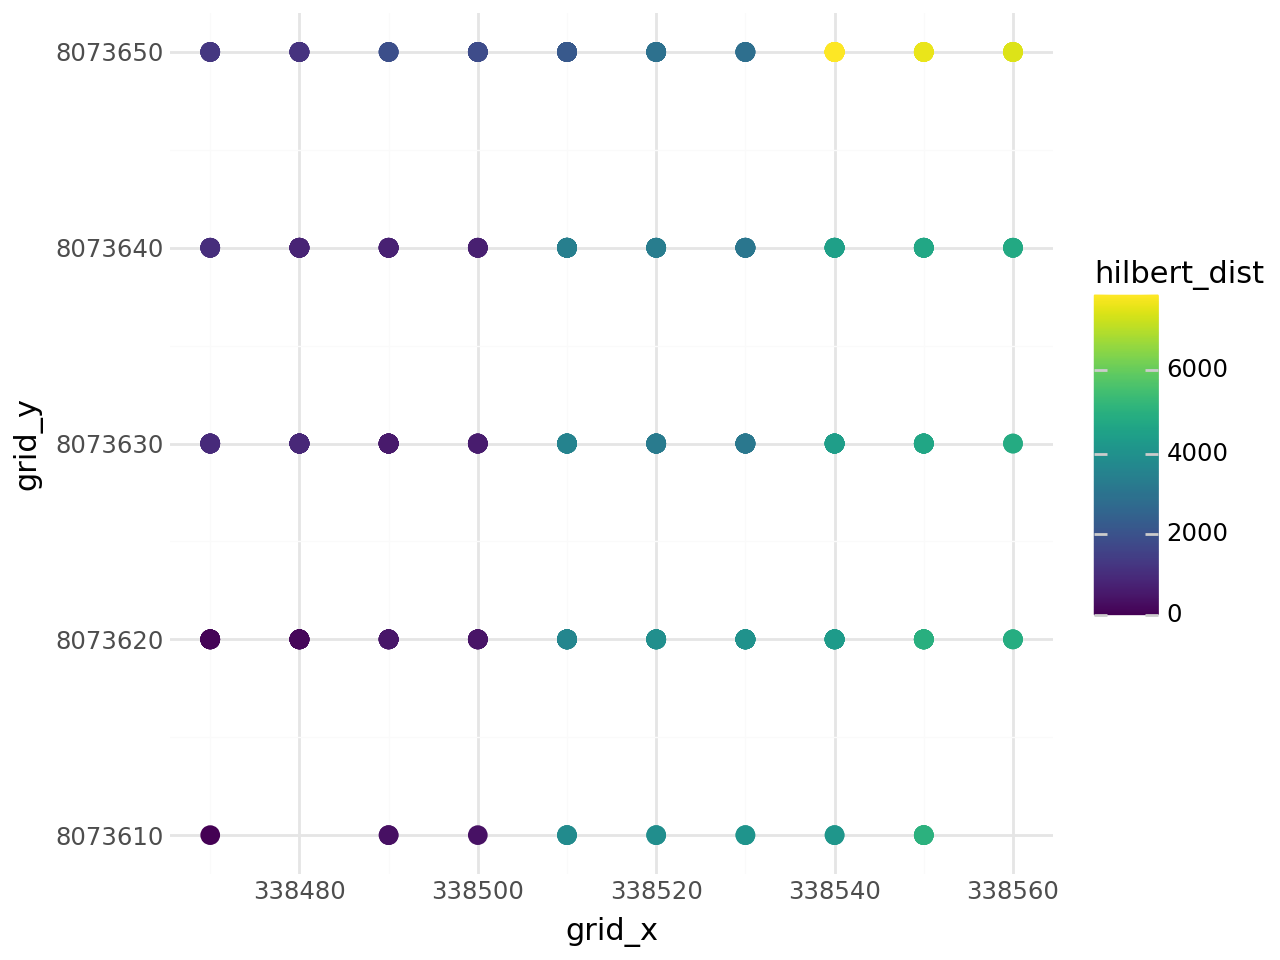

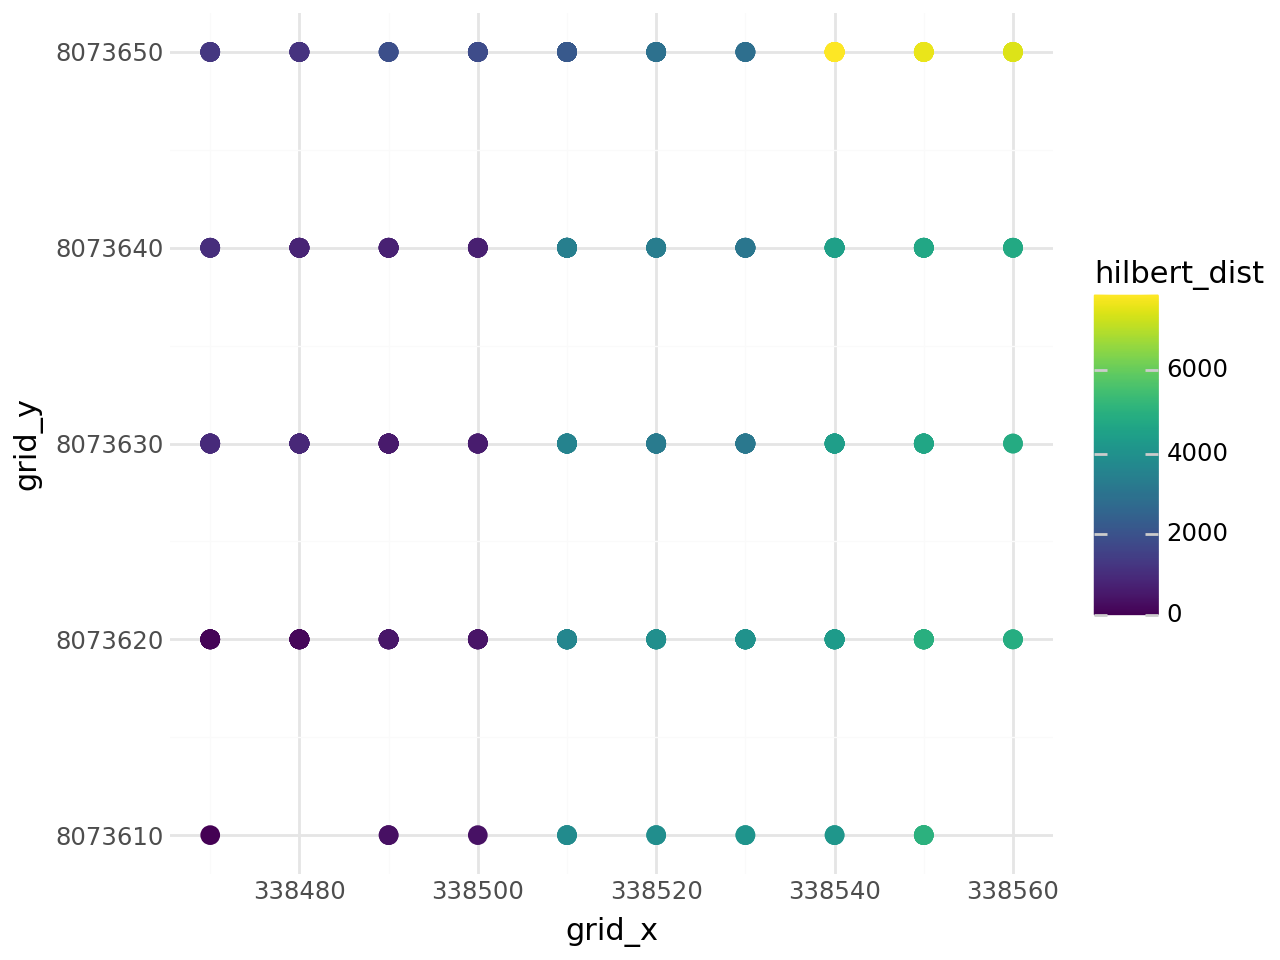

In [ ]:
(ggplot(df, aes(x='grid_x', y='grid_y', color='hilbert_dist')) +
 geom_point(size=3) +
 theme_minimal())


ok I am happy with this.

What is left to do:

- map a cell_id to a genus name using the hilbert distance order
- generate new tree names

can help me write some code

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Sure! Let's break it down into steps.

First, let's map cell_id to genus names. We need to:
1. Get unique cell_ids sorted by their Hilbert distance
2. Assign the 48 genus names you selected

Try this:

```python
cell_order = df.groupby('cell_id')['hilbert_dist'].first().sort_values()
cell_to_genus = dict(zip(cell_order.index, sorted(selected)))
```

Give that a try and let me know if it works!

In [ ]:
cell_order = df.groupby('cell_id')['hilbert_dist'].first().sort_values()
cell_to_genus = dict(zip(cell_order.index, sorted(selected)))

In [ ]:
cell_to_genus

{'338470_8073610': 'Aata',
 '338470_8073620': 'Abax',
 '338480_8073620': 'Bako',
 '338490_8073610': 'Bubo',
 '338500_8073610': 'Ceto',
 '338500_8073620': 'Daku',
 '338490_8073620': 'Ecto',
 '338490_8073630': 'Faba',
 '338500_8073630': 'Gaga',
 '338500_8073640': 'Hada',
 '338490_8073640': 'Iago',
 '338480_8073640': 'Jaya',
 '338480_8073630': 'Kali',
 '338470_8073630': 'Lama',
 '338470_8073640': 'Mada',
 '338480_8073650': 'Naia',
 '338470_8073650': 'Obus',
 '338500_8073650': 'Odax',
 '338490_8073650': 'Okea',
 '338510_8073650': 'Omus',
 '338530_8073650': 'Owra',
 '338520_8073650': 'Oxya',
 '338530_8073640': 'Paha',
 '338530_8073630': 'Psoa',
 '338520_8073630': 'Ptyx',
 '338520_8073640': 'Raja',
 '338510_8073640': 'Saba',
 '338510_8073630': 'Spio',
 '338510_8073620': 'Taia',
 '338510_8073610': 'Thor',
 '338520_8073610': 'Tyto',
 '338520_8073620': 'Uaru',
 '338530_8073620': 'Ubis',
 '338530_8073610': 'Ucla',
 '338540_8073610': 'Ugni',
 '338540_8073620': 'Ulva',
 '338540_8073630': 'Unio',
 

{'338470_8073610': 'Aata',
 '338470_8073620': 'Abax',
 '338480_8073620': 'Bako',
 '338490_8073610': 'Bubo',
 '338500_8073610': 'Ceto',
 '338500_8073620': 'Daku',
 '338490_8073620': 'Ecto',
 '338490_8073630': 'Faba',
 '338500_8073630': 'Gaga',
 '338500_8073640': 'Hada',
 '338490_8073640': 'Iago',
 '338480_8073640': 'Jaya',
 '338480_8073630': 'Kali',
 '338470_8073630': 'Lama',
 '338470_8073640': 'Mada',
 '338480_8073650': 'Naia',
 '338470_8073650': 'Obus',
 '338500_8073650': 'Odax',
 '338490_8073650': 'Okea',
 '338510_8073650': 'Omus',
 '338530_8073650': 'Owra',
 '338520_8073650': 'Oxya',
 '338530_8073640': 'Paha',
 '338530_8073630': 'Psoa',
 '338520_8073630': 'Ptyx',
 '338520_8073640': 'Raja',
 '338510_8073640': 'Saba',
 '338510_8073630': 'Spio',
 '338510_8073620': 'Taia',
 '338510_8073610': 'Thor',
 '338520_8073610': 'Tyto',
 '338520_8073620': 'Uaru',
 '338530_8073620': 'Ubis',
 '338530_8073610': 'Ucla',
 '338540_8073610': 'Ugni',
 '338540_8073620': 'Ulva',
 '338540_8073630': 'Unio',
 

In [ ]:
df['suffix']  = df['GIS_ID'].str.extract(r'\d{6}_\d{7}_(.+)')
df['pretty_name'] = df['cell_id'].map(cell_to_genus) + '_' + df['suffix']

In [ ]:
df[['pretty_name', 'GIS_ID']]

,pretty_name,GIS_ID
0,Aata_20_1,CRA01-01_338470_8073610_20_1
1,Abax_01_1,CRA01-01_338470_8073620_01_1
2,Abax_04,CRA01-01_338470_8073620_04
3,Abax_05,CRA01-01_338470_8073620_05
4,Abax_07_1,CRA01-01_338470_8073620_07_1
...,...,...
340,Zeus_21_b,CRA01-01_338560_8073650_21_b
341,Zeus_23_b,CRA01-01_338560_8073650_23_b
342,Zeus_24_b,CRA01-01_338560_8073650_24_b
343,Zeus_25_b,CRA01-01_338560_8073650_25_b


,pretty_name,GIS_ID
0,Aata_20_1,CRA01-01_338470_8073610_20_1
1,Abax_01_1,CRA01-01_338470_8073620_01_1
2,Abax_04,CRA01-01_338470_8073620_04
3,Abax_05,CRA01-01_338470_8073620_05
4,Abax_07_1,CRA01-01_338470_8073620_07_1
...,...,...
340,Zeus_21_b,CRA01-01_338560_8073650_21_b
341,Zeus_23_b,CRA01-01_338560_8073650_23_b
342,Zeus_24_b,CRA01-01_338560_8073650_24_b
343,Zeus_25_b,CRA01-01_338560_8073650_25_b


In [ ]:
df.drop(columns="tree_loc").to_file("the_crater_crowns.gpkg", driver="GPKG")

## Pretty name script


a python script that takes as cli arguments a folder (or *.las files) and a name to pretty name map and the gpkg file and renames everything. Add uv dependencies on top

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
# /// script
# dependencies = [
#   "geopandas",
# ]
# ///

import argparse
from pathlib import Path
import geopandas as gpd

def rename_files(folder, gpkg_path, dry_run=False):
    df = gpd.read_file(gpkg_path)
    name_map = dict(zip(df['GIS_ID'], df['pretty_name']))
    folder = Path(folder)
    las_files = list(folder.glob('*.las'))
    for f in las_files:
        stem = f.stem
        if stem in name_map:
            new_name = f.parent / f"{name_map[stem]}.las"
            print(f"{f.name} -> {new_name.name}")
            if not dry_run: f.rename(new_name)
        else: print(f"Skipping {f.name} (not in map)")

if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Rename LAS files using pretty names from GPKG')
    parser.add_argument('folder', help='Folder containing LAS files')
    parser.add_argument('gpkg', help='Path to GPKG file with name mapping')
    parser.add_argument('--dry-run', action='store_true', help='Preview changes without renaming')
    args = parser.parse_args()
    rename_files(args.folder, args.gpkg, args.dry_run)
```

# QGIS Action


now in QGIS I want an action that if I click on a element it gives me all the other elements in that radiues that are within 5? meters

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

For a QGIS action that shows nearby elements within 5 meters when you click, you'll want to create a Python action.

Go to Layer Properties → Actions → Add a new action with:

**Type:** Python

**Action text:**
```python
from qgis.utils import iface
layer = iface.activeLayer()
feat = layer.getFeature([% $id %])
geom = feat.geometry().buffer(5)
nearby = [f['pretty_name'] for f in layer.getFeatures() if f.id() != [% $id %] and f.geometry().intersects(geom)]
iface.messageBar().pushMessage("Nearby trees", ', '.join(nearby), duration=10)
```

**Name:** Show nearby (5m)

This will show a message bar with the pretty_name of all features within 5 meters when you click the action button. Want to adjust the field name or display method?

I don't like the message bar for the output

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

What would you prefer instead? Some options:

1. **Dialog box** - Pop-up window with the list
2. **Print to Python console** - Shows in QGIS Python console
3. **Select the features** - Highlights them on the map
4. **Show in attribute table** - Filters the attribute table

Which sounds best for your workflow?

An error occurred during execution of following code:
from qgis.utils import iface 
layer = iface.activeLayer() 
feat = layer.getFeature(22) 
geom = feat.geometry().buffer(5) 
nearby = [f['pretty_name'] for f in layer.getFeatures() if f.id() != 22 and f.geometry().intersects(geom)] 
iface.messageBar().pushMessage("Nearby trees", ', '.join(nearby), duration=10) 



Traceback (most recent call last):
  File "", line 4, in 
TypeError: QgsGeometry.buffer(): arguments did not match any overloaded call:
  overload 1: not enough arguments
  overload 2: not enough arguments



##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The `buffer()` method in QGIS requires more parameters. Try this instead:

```python
from qgis.utils import iface
layer = iface.activeLayer()
feat = layer.getFeature(22)
geom = feat.geometry().buffer(5, 5)
nearby = [f['pretty_name'] for f in layer.getFeatures() if f.id() != 22 and f.geometry().intersects(geom)]
iface.messageBar().pushMessage("Nearby trees", ', '.join(nearby), duration=10)
```

The second parameter (5) is the number of segments to use for approximating a quarter circle when creating rounded buffers.

I want it to open the attribute table  (if not already open), select the nearby tree and then show the table filtered

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Try this action code:

```python
from qgis.utils import iface
layer = iface.activeLayer()
feat = layer.getFeature([% $id %])
geom = feat.geometry().buffer(5, 5)
nearby_ids = [f.id() for f in layer.getFeatures() if f.id() != [% $id %] and f.geometry().intersects(geom)]
layer.selectByIds(nearby_ids)
iface.showAttributeTable(layer)
iface.actionFilterShowSelected().trigger()
```

This will select the nearby features, open the attribute table, and filter it to show only the selected features.

Traceback (most recent call last):
  File "", line 8, in 
AttributeError: 'QgisInterface' object has no attribute 'actionFilterShowSelected'

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The method name is different. Try this:

```python
from qgis.utils import iface
layer = iface.activeLayer()
feat = layer.getFeature([% $id %])
geom = feat.geometry().buffer(5, 5)
nearby_ids = [f.id() for f in layer.getFeatures() if f.id() != [% $id %] and f.geometry().intersects(geom)]
layer.selectByIds(nearby_ids)
iface.showAttributeTable(layer)
layer.setSubsetString(f'"fid" IN ({",".join(map(str, nearby_ids))})')
```

Actually, a simpler approach is to just select and let the user click the "Show Selected Features" button. Or we can use:

```python
from qgis.utils import iface
layer = iface.activeLayer()
feat = layer.getFeature([% $id %])
geom = feat.geometry().buffer(5, 5)
nearby_ids = [f.id() for f in layer.getFeatures() if f.id() != [% $id %] and f.geometry().intersects(geom)]
layer.selectByIds(nearby_ids)
iface.showAttributeTable(layer)
```

Then manually click the "Show Selected Features" filter button in the attribute table toolbar. Does that work for you?

I want for a QGIS layer count the number of true values in the segmented column. It needs to be computed dinamically

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You can add a virtual field in QGIS that counts the true values dynamically.

Go to Layer Properties → Fields → Field Calculator, and create a new virtual field with this expression:

```
aggregate(
  layer:=@layer_name,
  aggregate:='count',
  expression:="Segmented",
  filter:="Segmented" = 1
)
```

Or if you want it as a label or in the status bar, you can use this expression directly in the layer properties or as a Python expression in the console:

```python
from qgis.utils import iface
layer = iface.activeLayer()
count = sum(1 for f in layer.getFeatures() if f['Segmented'] == 1)
print(f"Segmented count: {count}")
```

Which approach would you prefer?

but I don't like having a field for aggregation, can I have something like layers actions?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You can use a **Custom Action** that displays the count when clicked!

Go to Layer Properties → Actions → Add new action:

**Type:** Python

**Action text:**
```python
from qgis.utils import iface
layer = iface.activeLayer()
count = sum(1 for f in layer.getFeatures() if f['Segmented'] == 1)
total = layer.featureCount()
from qgis.PyQt.QtWidgets import QMessageBox
QMessageBox.information(None, "Segmentation Progress", f"Segmented: {count}/{total} ({100*count/total:.1f}%)")
```

**Name:** Show segmentation count

This creates a clickable action that shows a dialog with the count. Want to adjust what it displays?

where will I click for layer actions?



##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Layer actions appear in different places depending on your QGIS setup:

1. **In the Attributes toolbar** - There's an "Run Layer Actions" button (lightning bolt icon)
2. **Right-click on a feature** in the map canvas - You'll see your actions in the context menu
3. **In the Attribute Table** - There's an actions column on the left side with dropdown buttons for each feature

The easiest way is usually the **Attributes toolbar** - look for the lightning bolt icon. If you don't see it, you can enable it by right-clicking on the toolbar area and checking "Attributes Toolbar".

For layer-level actions (not feature-specific), you might need to trigger them from the Python console or assign them to a toolbar button. Would you like help setting that up?